# ¿Los embeddings entienden el significado o solo cuentan palabras?

**Tarea opcional · Clase 3 · AI Engineering**

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chopliszt/coder-langchain/blob/main/semana-3/tarea-opcional-similitud/similitud_coseno_con_embeddings.ipynb)

**La pregunta:** si dos frases hablan de lo mismo con palabras distintas, ¿una computadora se da cuenta?
¿Y si dos frases comparten palabras pero hablan de cosas distintas, se deja engañar?

Vamos a comparar dos formas de medir qué tan parecidos son dos textos:

| Método | Cómo "ve" un texto | Analogía |
|---|---|---|
| **TF-IDF** (palabras) | Cuenta qué palabras aparecen | Un detector que solo mira **qué palabras** usás |
| **Embeddings** (significado) | Un modelo convierte el texto en coordenadas de significado | Un lector que entiende **de qué estás hablando** |

En los dos casos medimos la cercanía con **similitud coseno** de `scikit-learn`.

## 0. Preparación

En Google Colab, `scikit-learn` y `matplotlib` ya vienen instalados. Esta celda instala `sentence-transformers`
solo si falta. La primera vez descarga el modelo de embeddings (~1 GB), tarda un par de minutos.

In [1]:
import importlib.util
import logging
import os
import warnings

warnings.filterwarnings("ignore")
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

if importlib.util.find_spec("sentence_transformers") is None:
    get_ipython().run_line_magic("pip", "install -q sentence-transformers")

import matplotlib.pyplot as plt
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## 1. Las oraciones

- **5 oraciones reales**: todas hablan del **despliegue de microservicios**, pero con vocabulario distinto
  (casi no repiten palabras entre sí).
- **2 oraciones trampa**: comparten palabras clave (*despliegue, servicio, micro, producción*) pero hablan de otra cosa:
  limpieza de un edificio y un desfile.

In [2]:
oraciones_reales: list[str] = [
    "Publicamos cada microservicio en su propio contenedor y lo subimos al clúster de Kubernetes.",
    "Empaquetamos los módulos de la aplicación con Docker y los lanzamos a la nube por separado.",
    "Cada componente del sistema se pone en marcha de forma independiente, sin frenar a los demás.",
    "El pipeline de integración continua construye la imagen y la libera automáticamente en el orquestador.",
    "Dividimos el software en piezas autónomas que se instalan en servidores sin depender unas de otras.",
]
oraciones_trampa: list[str] = [
    "El despliegue del servicio de micro limpieza en producción del edificio fue excelente.",
    "En el desfile, el despliegue de la bandera fue un servicio de producción del microcentro.",
]
todas_las_oraciones: list[str] = oraciones_reales + oraciones_trampa
etiquetas_cortas: list[str] = ["Real 1", "Real 2", "Real 3", "Real 4", "Real 5", "Trampa 1", "Trampa 2"]

for etiqueta, oracion in zip(etiquetas_cortas, todas_las_oraciones):
    print(f"{etiqueta:<9} {oracion}")

Real 1    Publicamos cada microservicio en su propio contenedor y lo subimos al clúster de Kubernetes.
Real 2    Empaquetamos los módulos de la aplicación con Docker y los lanzamos a la nube por separado.
Real 3    Cada componente del sistema se pone en marcha de forma independiente, sin frenar a los demás.
Real 4    El pipeline de integración continua construye la imagen y la libera automáticamente en el orquestador.
Real 5    Dividimos el software en piezas autónomas que se instalan en servidores sin depender unas de otras.
Trampa 1  El despliegue del servicio de micro limpieza en producción del edificio fue excelente.
Trampa 2  En el desfile, el despliegue de la bandera fue un servicio de producción del microcentro.


## 2. ¿Qué es la similitud coseno? (y cómo se calcula con scikit-learn)

Un texto convertido a números es un **vector**: una flecha en un espacio de muchas dimensiones.
La similitud coseno mide **el ángulo** entre dos flechas:

$$\text{similitud coseno}(A, B) = \frac{A \cdot B}{\|A\| \, \|B\|}$$

- **1** → apuntan hacia el mismo lado (mismo tema)
- **0** → perpendiculares (nada que ver)

**Analogía:** dos personas señalando con el brazo. No importa si uno tiene el brazo más largo: importa si **señalan hacia el mismo lugar**.

Primero, un ejemplo con vectores chiquitos, calculado a mano con NumPy y con `cosine_similarity` de scikit-learn:

In [3]:
vector_a: np.ndarray = np.array([[1.0, 2.0, 3.0]])
vector_b: np.ndarray = np.array([[2.0, 4.0, 6.0]])
vector_c: np.ndarray = np.array([[-3.0, 0.0, 1.0]])

def calcular_similitud_coseno_a_mano(vector_uno: np.ndarray, vector_dos: np.ndarray) -> float:
    producto_punto: float = float(np.dot(vector_uno.ravel(), vector_dos.ravel()))
    largos_multiplicados: float = float(np.linalg.norm(vector_uno) * np.linalg.norm(vector_dos))
    return producto_punto / largos_multiplicados

print("A y B (misma dirección, distinto largo)")
print("  a mano:       ", round(calcular_similitud_coseno_a_mano(vector_a, vector_b), 3))
print("  scikit-learn: ", round(float(cosine_similarity(vector_a, vector_b)[0, 0]), 3))
print("A y C (direcciones distintas)")
print("  a mano:       ", round(calcular_similitud_coseno_a_mano(vector_a, vector_c), 3))
print("  scikit-learn: ", round(float(cosine_similarity(vector_a, vector_c)[0, 0]), 3))

A y B (misma dirección, distinto largo)
  a mano:        1.0
  scikit-learn:  1.0
A y C (direcciones distintas)
  a mano:        0.0
  scikit-learn:  0.0


`cosine_similarity(X, Y)` recibe **matrices** (una fila por vector) y devuelve **una tabla** con la similitud de cada fila
de `X` contra cada fila de `Y`. Por eso sirve igual para comparar 2 vectores o 7 oraciones contra 7 oraciones.

## 3. Método A: TF-IDF (solo palabras)

`TfidfVectorizer` convierte cada oración en un vector donde cada posición es **una palabra del vocabulario**.
Dos oraciones se parecen solo si **comparten palabras**.

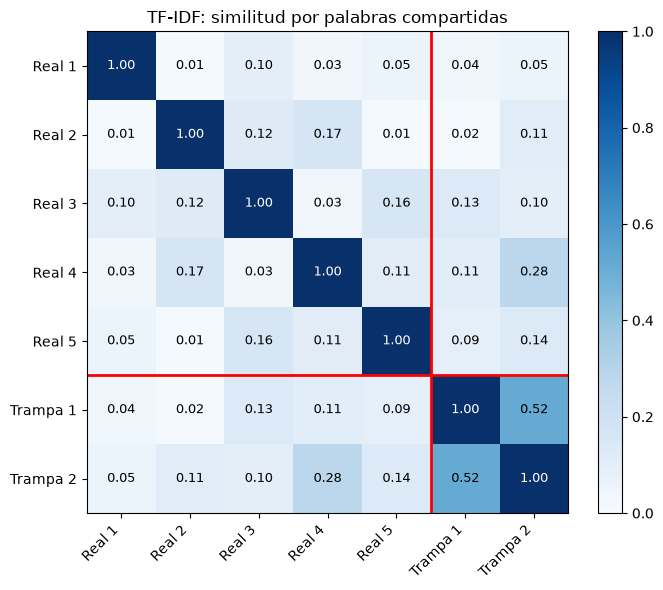

In [4]:
def dibujar_mapa_de_calor(matriz_de_similitud: np.ndarray, titulo: str) -> None:
    figura, eje = plt.subplots(figsize=(7, 6))
    imagen = eje.imshow(matriz_de_similitud, cmap="Blues", vmin=0, vmax=1)
    eje.set_xticks(range(len(etiquetas_cortas)), etiquetas_cortas, rotation=45, ha="right")
    eje.set_yticks(range(len(etiquetas_cortas)), etiquetas_cortas)
    for fila in range(len(etiquetas_cortas)):
        for columna in range(len(etiquetas_cortas)):
            valor: float = matriz_de_similitud[fila, columna]
            eje.text(columna, fila, f"{valor:.2f}", ha="center", va="center", color="white" if valor > 0.6 else "black", fontsize=9)
    eje.axhline(4.5, color="red", linewidth=2)
    eje.axvline(4.5, color="red", linewidth=2)
    eje.set_title(titulo)
    figura.colorbar(imagen, ax=eje, fraction=0.046)
    plt.tight_layout()
    plt.show()

convertidor_tfidf: TfidfVectorizer = TfidfVectorizer()
vectores_tfidf = convertidor_tfidf.fit_transform(todas_las_oraciones)
similitud_tfidf: np.ndarray = cosine_similarity(vectores_tfidf)

dibujar_mapa_de_calor(similitud_tfidf, "TF-IDF: similitud por palabras compartidas")

**Cómo leerlo:** el cuadrado de arriba a la izquierda (reales contra reales) debería ser **oscuro** si el método
entiende que hablan de lo mismo. Con TF-IDF está casi **blanco**: como no comparten palabras, para TF-IDF son textos distintos.

## 4. Método B: embeddings (significado)

Usamos un modelo **multilingüe** (entiende español) de `sentence-transformers`. Cada oración se convierte en un vector
de **768 números** que representa su significado.

Forma de los vectores: (7, 768) -> 7 oraciones, 768 números cada una


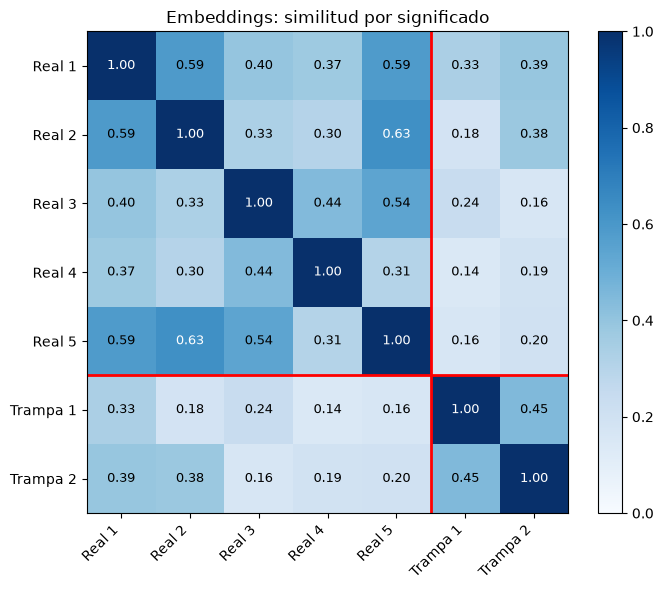

In [5]:
NOMBRE_DEL_MODELO_DE_EMBEDDINGS: str = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

modelo_de_embeddings: SentenceTransformer = SentenceTransformer(NOMBRE_DEL_MODELO_DE_EMBEDDINGS, device="cpu")
vectores_de_significado: np.ndarray = modelo_de_embeddings.encode(todas_las_oraciones, normalize_embeddings=True)
similitud_por_significado: np.ndarray = cosine_similarity(vectores_de_significado)

print("Forma de los vectores:", vectores_de_significado.shape, "-> 7 oraciones, 768 números cada una")
dibujar_mapa_de_calor(similitud_por_significado, "Embeddings: similitud por significado")

**Cómo leerlo:** ahora el cuadrado de las reales es **bastante más oscuro** que las celdas que cruzan reales con trampas.
El modelo entiende que *"contenedor en Kubernetes"* y *"piezas autónomas en servidores"* hablan de lo mismo, aunque no compartan palabras.

## 5. Comparación en números

Promedio de similitud dentro de cada grupo. Lo ideal: **alta entre reales** y **baja entre reales y trampas**.

In [6]:
def resumir_similitud_por_grupos(matriz_de_similitud: np.ndarray) -> tuple[float, float]:
    cantidad_de_reales: int = len(oraciones_reales)
    bloque_reales: np.ndarray = matriz_de_similitud[:cantidad_de_reales, :cantidad_de_reales]
    fuera_de_la_diagonal: np.ndarray = ~np.eye(cantidad_de_reales, dtype=bool)
    promedio_entre_reales: float = float(bloque_reales[fuera_de_la_diagonal].mean())
    promedio_reales_contra_trampas: float = float(matriz_de_similitud[:cantidad_de_reales, cantidad_de_reales:].mean())
    return promedio_entre_reales, promedio_reales_contra_trampas

print(f"{'Método':<28}{'Entre reales':>14}{'Reales vs trampas':>20}")
for nombre_del_metodo, matriz in [("TF-IDF (palabras)", similitud_tfidf), ("Embeddings (significado)", similitud_por_significado)]:
    entre_reales, contra_trampas = resumir_similitud_por_grupos(matriz)
    print(f"{nombre_del_metodo:<28}{entre_reales:>14.2f}{contra_trampas:>20.2f}")

Método                        Entre reales   Reales vs trampas
TF-IDF (palabras)                     0.08                0.11
Embeddings (significado)              0.45                0.24


## 6. Un mapa del significado

Los vectores tienen 768 dimensiones: imposible de dibujar. `PCA` de scikit-learn los **resume en 2 dimensiones**
(como sacar una foto de una escultura: se pierde algo, pero se ve la forma). Si el modelo entiende, las 5 reales
deberían quedar **juntas** y las trampas **aparte**.

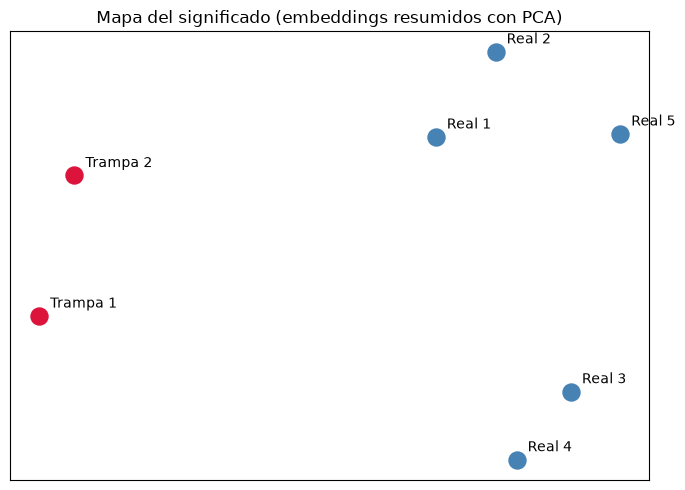

In [7]:
coordenadas_en_dos_dimensiones: np.ndarray = PCA(n_components=2, random_state=0).fit_transform(vectores_de_significado)

figura, eje = plt.subplots(figsize=(7, 5))
for indice, etiqueta in enumerate(etiquetas_cortas):
    es_trampa: bool = etiqueta.startswith("Trampa")
    eje.scatter(*coordenadas_en_dos_dimensiones[indice], s=150, color="crimson" if es_trampa else "steelblue")
    eje.annotate(etiqueta, coordenadas_en_dos_dimensiones[indice], textcoords="offset points", xytext=(8, 6))
eje.set_title("Mapa del significado (embeddings resumidos con PCA)")
eje.set_xticks([])
eje.set_yticks([])
plt.tight_layout()
plt.show()

## 7. Búsqueda semántica: ¿qué documento devuelve?

Simulamos un buscador: llega una **consulta**, la convertimos en vector y la comparamos con las 7 oraciones.

Probamos dos consultas:
1. **Estilo palabras clave:** `despliegue de microservicios en producción`
2. **Pregunta natural:** `¿Cómo pongo en marcha una aplicación dividida en partes independientes?`

In [8]:
def buscar_las_oraciones_mas_parecidas(consulta: str, cantidad_de_resultados: int = 3) -> None:
    similitud_tfidf_con_la_consulta: np.ndarray = cosine_similarity(convertidor_tfidf.transform([consulta]), vectores_tfidf)[0]
    vector_de_la_consulta: np.ndarray = modelo_de_embeddings.encode([consulta], normalize_embeddings=True)
    similitud_semantica_con_la_consulta: np.ndarray = cosine_similarity(vector_de_la_consulta, vectores_de_significado)[0]

    print(f"Consulta: {consulta}")
    for nombre_del_metodo, similitudes in [("TF-IDF", similitud_tfidf_con_la_consulta), ("Embeddings", similitud_semantica_con_la_consulta)]:
        posiciones_ordenadas: np.ndarray = np.argsort(similitudes)[::-1][:cantidad_de_resultados]
        resultados: str = " | ".join(f"{etiquetas_cortas[posicion]} ({similitudes[posicion]:.2f})" for posicion in posiciones_ordenadas)
        print(f"  {nombre_del_metodo:<11} top {cantidad_de_resultados}: {resultados}")
    print()

buscar_las_oraciones_mas_parecidas("despliegue de microservicios en producción")
buscar_las_oraciones_mas_parecidas("¿Cómo pongo en marcha una aplicación dividida en partes independientes?")

Consulta: despliegue de microservicios en producción
  TF-IDF      top 3: Trampa 2 (0.46) | Trampa 1 (0.43) | Real 5 (0.13)
  Embeddings  top 3: Trampa 2 (0.67) | Real 1 (0.45) | Trampa 1 (0.44)



Consulta: ¿Cómo pongo en marcha una aplicación dividida en partes independientes?
  TF-IDF      top 3: Real 3 (0.25) | Real 2 (0.16) | Real 5 (0.15)
  Embeddings  top 3: Real 5 (0.65) | Real 2 (0.56) | Real 1 (0.47)



## 8. Diagrama de flujo de una búsqueda semántica

![Diagrama de flujo de la búsqueda semántica](https://raw.githubusercontent.com/chopliszt/coder-langchain/main/semana-3/tarea-opcional-similitud/diagrama_busqueda_semantica.png)

## 9. Pseudocódigo del cálculo de similitud

```
ANTES (una sola vez):
    para cada documento:
        vector_del_documento = modelo_de_embeddings(documento)
        guardar vector_del_documento en la base de vectores

EN CADA BÚSQUEDA:
    vector_de_la_consulta = MISMO modelo_de_embeddings(consulta)
    para cada vector_del_documento en la base:
        similitud = (vector_de_la_consulta · vector_del_documento) / (|vector_de_la_consulta| * |vector_del_documento|)
    ordenar documentos por similitud, de mayor a menor
    si la mejor similitud < umbral:
        responder "no encontré nada relevante"
    si no:
        devolver los k documentos más parecidos
```

En Python con scikit-learn, todo el bucle es una línea: `cosine_similarity(vector_de_la_consulta, vectores_de_los_documentos)`.

## 10. Análisis y conclusiones

1. **TF-IDF no ve el significado.** Las 5 oraciones reales casi no se parecen entre sí para TF-IDF, porque usan palabras
   distintas. Y ante la consulta con palabras clave, elige **las trampas**, porque son las que comparten *despliegue*, *servicio* y *producción*.
2. **Los embeddings sí agrupan por significado.** Las 5 reales quedan claramente más cerca entre sí que de las trampas
   (mapa de calor y mapa PCA), aunque casi no compartan palabras.
3. **Pero no son mágicos.** Con una consulta que es solo una lista de palabras clave, el modelo también se tienta con las
   trampas: las palabras repetidas tiran fuerte. Con una **pregunta natural**, el top 3 de los embeddings son todas
   oraciones reales y con similitudes altas (0,65). TF-IDF también acierta esta vez, pero solo porque la pregunta comparte
   palabras sueltas (*marcha*, *aplicación*, *independiente*) y con similitudes bajas (0,25): si la pregunta usara otras palabras, fallaría.
   Lección práctica: en un sistema RAG conviene que la consulta sea una pregunta completa, o reescribirla con un LLM antes de buscar.
4. **Por eso existe la búsqueda híbrida** (clase 4): BM25 (palabras exactas) + embeddings (significado), fusionados por ranking.
   Cada uno tapa los puntos ciegos del otro.
5. **El modelo importa.** Un modelo chico (como `paraphrase-multilingual-MiniLM-L12-v2`) separa los grupos menos que este;
   conviene probar el modelo con ejemplos propios, como acá, antes de elegirlo.

**Regla de oro:** indexar y consultar con **el mismo** modelo de embeddings; si no, las coordenadas no son comparables.

## 11. Para practicar (ideas para clase)

- Cambiá las oraciones por un tema de tu materia (por ejemplo, fotosíntesis) y creá tus propias trampas.
- Probá con `"sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"` en `NOMBRE_DEL_MODELO_DE_EMBEDDINGS` y compará la tabla del punto 5.
- Escribí una consulta en otro idioma (inglés): ¿el modelo multilingüe la entiende igual?